#  Driver Drowsiness Detection System

This notebook implements a complete driver drowsiness detection system using deep learning and facial landmark analysis. The pipeline begins by preprocessing the **YawDD dataset**, where videos are parsed to extract face sequences using **MediaPipe Face Mesh**. Each video sequence is labeled based on yawning behavior, either directly from the filename (for Mirror camera) or by computing **mouth openness** using facial landmarks (for Dash camera). These labeled face sequences are saved as `.npy` files, which are then used to train a **CNN-LSTM model** with **MobileNetV2** as the backbone for spatial feature extraction and an **LSTM** layer for learning temporal patterns in driver behavior.

Once trained on the YawDD dataset, the model is **fine-tuned using the NTHU drowsiness dataset** to adapt it to more diverse driving scenarios and improve generalization. The NTHU sequences are already preprocessed into labeled `.npy` files and loaded through a custom data generator. The final fine-tuned model—trained sequentially on **YawDD** and then **NTHU**—is used in a **real-time testing module** that captures webcam input, processes face frames on the fly, and predicts whether the driver is **drowsy or alert**. 

This end-to-end pipeline—from data preprocessing to real-time inference—results in a practical and efficient driver monitoring system. The real-time detection module combines predictions from the fine-tuned CNN-LSTM model with facial landmark-based **Eye Aspect Ratio (EAR)** analysis. Sequences of face frames are passed through the model to predict drowsiness, while EAR is simultaneously computed to detect eye closure over time. A voting mechanism merges these two signals: if either the model predicts "DROWSY" or the eyes remain closed for a certain duration, the system classifies the driver as drowsy with high confidence. This dual approach improves the robustness and reliability of drowsiness detection in real-world conditions.

## 📁 Dataset References

### 🔹 YawDD Dataset (Yawning Detection Dataset)
- **Official Link:** [IEEE Dataport – YawDD](https://ieee-dataport.org/open-access/yawdd-yawning-detection-dataset)  
- **Kaggle Mirror:** [Kaggle – YawDD Dataset](https://www.kaggle.com/datasets/enider/yawdd-dataset)  
- **Description:**  
  The YawDD dataset contains dashcam videos of drivers, annotated for yawning behavior. It is widely used for training models to detect signs of fatigue by analyzing mouth movements. This dataset is especially helpful for developing initial models for yawning detection.


### 🔹 NTHU Drowsiness Detection Dataset
- **Official Link:** [NTHU Dataset Page](http://cv.cs.nthu.edu.tw/php/callforpaper/datasets/DDD/)  
- **Kaggle Mirror:** [Kaggle – NTHU DDD Dataset](https://www.kaggle.com/datasets/banudeep/nthuddd2)  
- **Description:**  
  The NTHU dataset includes a wide range of video sequences with simulated drowsiness scenarios across various lighting and accessory conditions (e.g., night, sunglasses, glasses). It is a robust dataset often used for fine-tuning drowsiness detection models trained on simpler datasets like YawDD.

## 1. Setup and Installation

In [7]:
# Install required packages
# !pip install opencv-python-headless numpy mediapipe tensorflow scikit-learn tqdm matplotlib

## 2. Imports and Configuration

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, TimeDistributed, LSTM, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import Sequence
import os
import cv2
import numpy as np
import mediapipe as mp
import tensorflow as tf
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import tensorflow as tf

warnings.filterwarnings('ignore')

# Constants
SEQUENCE_LENGTH = 10 # Number of frames in each sequence
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 22
LEARNING_RATE = 1e-4

# YawDD-specific paths
DATASET_BASE = '/content/drive/MyDrive/DrowsinessProject/datasets/YawDD'
OUTPUT_PATH = 'YawDD_sequences'
# os.makedirs(OUTPUT_PATH, exist_ok=True)

## 3. Initialize MediaPipe with Mouth Landmarks

In [ ]:
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,  # Crucial for mouth detection
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5)

I0000 00:00:1746442639.437808 4898892 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


W0000 00:00:1746442639.442957 4912142 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 4. YawDD Data Processing

In [11]:
def process_yawdd_dataset():
    """Process both Mirror and Dash camera videos"""
    for camera_type in ['Mirror', 'Dash']:
        camera_path = os.path.join(DATASET_BASE, camera_type)
        if not os.path.exists(camera_path):
            print(f"{camera_path} not found! Skipping...")
            continue

        for gender in ['Male', 'Female']:
            # Handle YawDD's naming convention
            gender_folder = f"{gender}_mirror" if camera_type == 'Mirror' else gender
            gender_path = os.path.join(camera_path, gender_folder)

            if not os.path.exists(gender_path):
                print(f"{gender_path} not found! Skipping...")
                continue

            # Process all AVI files
            videos = [f for f in os.listdir(gender_path) if f.endswith('.avi')]
            for video in tqdm(videos, desc=f"Processing {camera_type}/{gender}"):
                video_path = os.path.join(gender_path, video)

                # Determine label from filename (Mirror) or mouth landmarks (Dash)
                if camera_type == 'Mirror':
                    # Mirror filenames: [Gender]-[ID]-[Condition].avi
                    condition = video.split('-')[-1].split('.')[0].lower()
                    label = 1 if 'yawn' in condition else 0
                else:
                    label = -1  # Will be determined per-frame

                extract_face_sequence(video_path, label, camera_type)

In [12]:
def extract_face_sequence(video_path, label, camera_type):
    """Extract sequences with mouth landmark analysis"""
    cap = cv2.VideoCapture(video_path)
    sequence = []
    count = 0
    vid_name = os.path.basename(video_path).split('.')[0]

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (320, 240))
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb_frame)

        if results.multi_face_landmarks:
            for landmarks in results.multi_face_landmarks:
                # Get bounding box
                xs = [lm.x for lm in landmarks.landmark]
                ys = [lm.y for lm in landmarks.landmark]
                h, w = frame.shape[:2]

                x_min = max(0, int(min(xs) * w) - 20)
                x_max = min(w, int(max(xs) * w) + 20)
                y_min = max(0, int(min(ys) * h) - 20)
                y_max = min(h, int(max(ys) * h) + 20)

                # Special handling for Dash camera videos
                if camera_type == 'Dash' and label == -1:
                    # Mouth landmarks: [13, 14, 78, 308] for mouth openness
                    mouth_top = landmarks.landmark[13].y
                    mouth_bottom = landmarks.landmark[14].y
                    mouth_openness = abs(mouth_top - mouth_bottom)
                    label = 1 if mouth_openness > 0.1 else 0  # Yawn threshold

                # Crop and resize face
                face = frame[y_min:y_max, x_min:x_max]
                if face.size == 0:
                    continue

                face = cv2.resize(face, IMG_SIZE)
                sequence.append(face)

                if len(sequence) == SEQUENCE_LENGTH:
                    seq_array = np.array(sequence) / 255.0  # Normalize
                    # Save with camera type prefix
                    np.save(os.path.join(OUTPUT_PATH, f'{camera_type[:3]}_{label}_{vid_name}_seq{count}.npy'), seq_array)
                    count += 1
                    sequence = []

    cap.release()

W0000 00:00:1746442639.457553 4912142 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 5. Model Architecture

### Mobilenetv2_LSTM Model

In [ ]:
def create_mobilenet_lstm():
    """Hybrid model with MobileNetV2 + LSTM for drowsiness detection"""
    # Load MobileNetV2 (pre-trained on ImageNet, exclude top layers)
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )
    base_model.trainable = False  # Freeze layers initially

    model = Sequential([
        # TimeDistributed wrapper for MobileNetV2 (process each frame)
        TimeDistributed(base_model, input_shape=(SEQUENCE_LENGTH, *IMG_SIZE, 3)),
        # Reduce spatial dimensions
        TimeDistributed(GlobalAveragePooling2D()),
        # LSTM for temporal modeling
        LSTM(64, dropout=0.2, recurrent_dropout=0.2),
        # Output layer (binary classification: drowsy/alert)
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

## 6. Training Pipeline

In [16]:
def load_processed_data():
    """Load processed YawDD sequences"""
    X, y = [], []
    for file in os.listdir(OUTPUT_PATH):
        if file.endswith('.npy'):
            # Extract label from filename (0 or 1 after camera prefix)
            label = int(file.split('_')[1])
            seq = np.load(os.path.join(OUTPUT_PATH, file))
            X.append(seq)
            y.append(label)
    return np.array(X), np.array(y)

def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

## 7. Visualization Functions

In [18]:
def plot_training_history(history):
    """Plot accuracy and loss curves"""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred):
    """Plot confusion matrix with Seaborn"""
    cm = confusion_matrix(y_true, y_pred > 0.5)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Alert', 'Drowsy'],
                yticklabels=['Alert', 'Drowsy'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred > 0.5, target_names=['Alert', 'Drowsy']))


def visualize_predictions(model, generator, n_samples=5):
    """Show sample predictions with frames and color-coded correctness"""

    batch_index = random.randint(0, len(generator) - 1)
    X, y = generator[batch_index]

    indices = random.sample(range(len(X)), min(n_samples, len(X)))
    X_sample = X[indices]
    y_sample = y[indices]

    preds = model.predict(X_sample)

    plt.figure(figsize=(3 * n_samples, 3))
    for i in range(len(indices)):
        plt.subplot(1, n_samples, i + 1)

        img = X_sample[i][SEQUENCE_LENGTH // 2]
        
        if img.max() <= 1.0:
            img = (img * 255).astype('uint8')
        else:
            img = img.astype('uint8')  
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        
        plt.imshow(img)
        
        pred_label = 1 if preds[i][0] >= 0.5 else 0
        true_label = y_sample[i]
        color = 'green' if pred_label == true_label else 'red'

        plt.title(f"T:{true_label} P:{pred_label}\n{preds[i][0]:.2f}", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


## 8. Main Execution

In [19]:
# Process dataset (uncomment to run)
# process_yawdd_dataset()

In [20]:
class NPYDataGenerator(Sequence):
    def __init__(self, file_list, batch_size, img_size, seq_length, shuffle=True):
        self.file_list = file_list
        self.batch_size = batch_size
        self.img_size = img_size
        self.seq_length = seq_length
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.file_list) / self.batch_size))

    def __getitem__(self, index):
        batch_files = self.file_list[index * self.batch_size:(index + 1) * self.batch_size]
        X, y = self.__data_generation(batch_files)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.file_list)

    def __data_generation(self, batch_files):
        X = []
        y = []
        for file in batch_files:
            path = os.path.join(OUTPUT_PATH, file)
            data = np.load(path)  # shape: (sequence_length, h, w, 3)

            # Resize each frame in the sequence to img_size
            resized_sequence = []
            for frame in data:
                resized = cv2.resize(frame, self.img_size)
                resized_sequence.append(resized)

            resized_sequence = np.array(resized_sequence)  # shape: (seq_length, img_size[0], img_size[1], 3)
            X.append(resized_sequence)

            label = int(file.split('_')[1])  # adjust if label position differs
            y.append(label)

        return np.array(X), np.array(y)

In [21]:
# Get list of .npy files
all_files = [f for f in os.listdir(OUTPUT_PATH) if f.endswith('.npy')]
train_files, test_files = train_test_split(all_files, test_size=0.2, random_state=42)

train_gen = NPYDataGenerator(train_files, BATCH_SIZE, IMG_SIZE, SEQUENCE_LENGTH)
test_gen = NPYDataGenerator(test_files, BATCH_SIZE, IMG_SIZE, SEQUENCE_LENGTH)

### Train MobilenetV2+LSTM Model

In [ ]:
# Build the model
mobilenet_model = create_mobilenet_lstm()
mobilenet_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 30, 7, 7, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,369 (9.93 MB)

 Trainable params: 344,385 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# 1. Define Model
def create_mobilenet_lstm():
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    model = Sequential([
        TimeDistributed(base_model, input_shape=(SEQUENCE_LENGTH, 224, 224, 3)),
        TimeDistributed(GlobalAveragePooling2D()),
        LSTM(64, dropout=0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# 2. Instantiate Model
mobilenet_model = create_mobilenet_lstm()

# 3. Define Callbacks
callbacks = [
    ModelCheckpoint(
        'best_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

# 4. Train
history = mobilenet_model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    validation_data=test_gen,
    validation_steps=len(test_gen),
    epochs=EPOCHS,
    callbacks=callbacks
)

In [ ]:
mobilenet_model.save('mobilenet_model.keras')



In [ ]:
# Evaluate
test_loss, test_acc = mobilenet_model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

28/28 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.9340 - loss: 0.1771
Test Accuracy: 92.86%


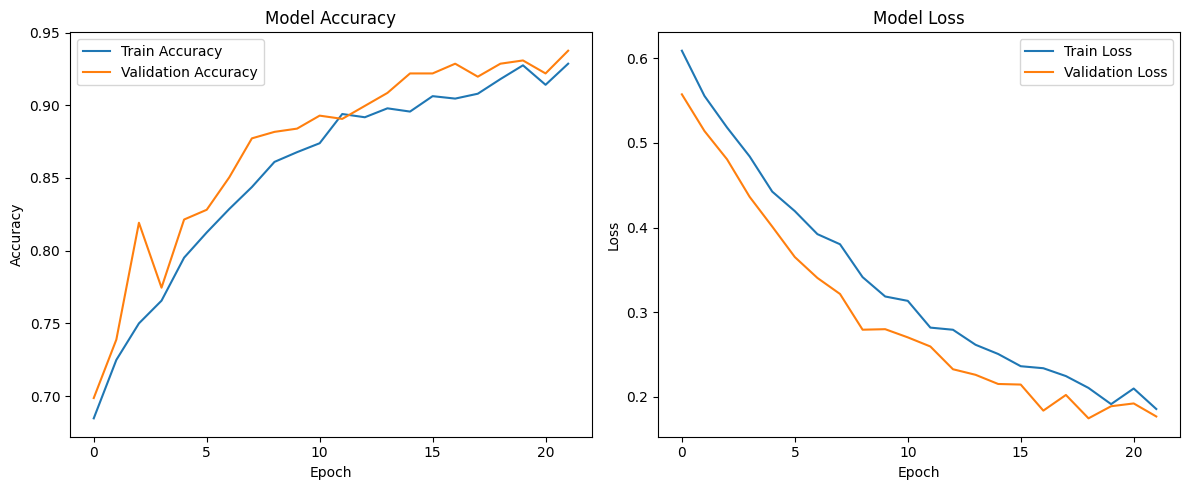

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate and visualize
y_true = np.concatenate([test_gen[i][1] for i in range(len(test_gen))])
y_pred = mobilenet_model.predict(test_gen)


28/28 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step


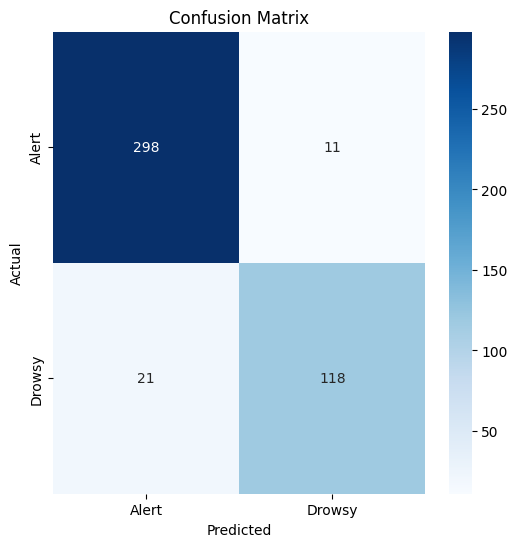


Classification Report:
              precision    recall  f1-score   support

       Alert       0.93      0.96      0.95       309
      Drowsy       0.91      0.85      0.88       139

    accuracy                           0.93       448
   macro avg       0.92      0.91      0.91       448
weighted avg       0.93      0.93      0.93       448

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


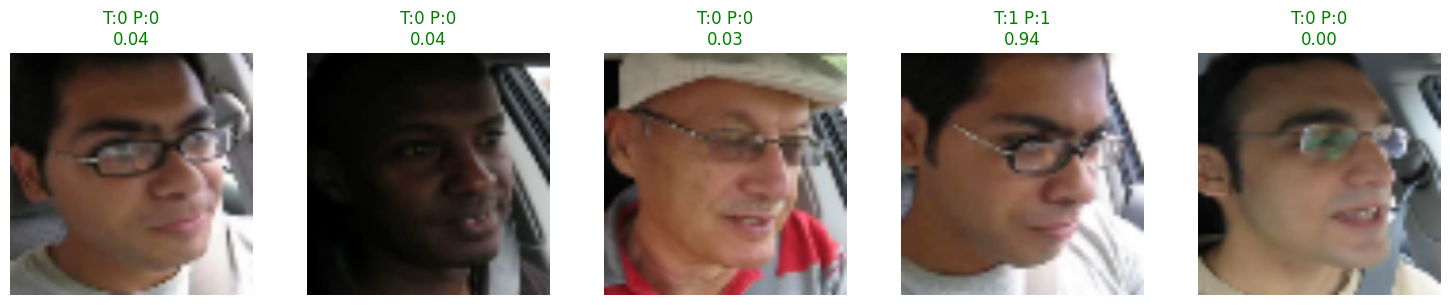

In [ ]:
# Confusion matrix
plot_confusion_matrix(y_true, y_pred)

# Sample predictions
visualize_predictions(mobilenet_model, test_gen, n_samples=5)

## 9. Save/Load Model

In [ ]:
# Save
# model.save('yawdd_drowsiness_model.keras')

# # Load
# model = tf.keras.models.load_model('yawdd_drowsiness_model.keras')

In [ ]:
OUTPUT_PATH = 'YawDD_sequences'
print(f"Processed sequences in {OUTPUT_PATH}: {len(os.listdir(OUTPUT_PATH))}")

# Training frames:
# 1792 sequences * 10 frames/sequence = 17,920 frames

# Validation frames:
# 448 sequences * 10 frames/sequence = 4,480 frames

Processed sequences in YawDD_sequences: 2240


## 10.  Fine-Tuning YawDD-Trained Model on NTHU Dataset

In this section, we fine-tune the pre-trained MobileNetV2 model (initially trained on the YawDD dataset) using the NTHU sequence dataset. The NTHU dataset consists of preprocessed 10-frame facial sequences labeled as drowsy and alert.

Note: This fine-tuning was performed on Google Colab, and the final model achieved approximately 80% validation accuracy on the NTHU dataset.

In [ ]:
# Configuration
SEQ_LENGTH = 10
IMG_SIZE = (224, 224)  # MobileNetV2 input size
BATCH_SIZE = 16
EPOCHS = 12

# Paths
NTHU_SEQ_DIR = "drive/MyDrive/DrowsinessProject/datasets/NTHU_sequences"
DROWSY_DIR = os.path.join(NTHU_SEQ_DIR, "drowsy")
NOTDROWSY_DIR = os.path.join(NTHU_SEQ_DIR, "alert")

# 1. Load and prepare dataset
class NTHUSequenceGenerator(Sequence):
    def __init__(self, seq_paths, labels, batch_size=BATCH_SIZE, shuffle=True):
        self.seq_paths = seq_paths
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.seq_paths) / self.batch_size))
    
    def __getitem__(self, index):
        batch_paths = self.seq_paths[index*self.batch_size:(index+1)*self.batch_size]
        batch_labels = self.labels[index*self.batch_size:(index+1)*self.batch_size]
        
        X = np.array([np.load(path) for path in batch_paths])
        y = np.array(batch_labels)
        return X, y
    
    def on_epoch_end(self):
        if self.shuffle:
            indices = np.random.permutation(len(self.seq_paths))
            self.seq_paths = [self.seq_paths[i] for i in indices]
            self.labels = [self.labels[i] for i in indices]

# Load all sequence paths
drowsy_seqs = [os.path.join(DROWSY_DIR, f) for f in os.listdir(DROWSY_DIR) if f.endswith('.npy')]
notdrowsy_seqs = [os.path.join(NOTDROWSY_DIR, f) for f in os.listdir(NOTDROWSY_DIR) if f.endswith('.npy')]

# Create labels (1 for drowsy, 0 for alert)
X = drowsy_seqs + notdrowsy_seqs
y = [1]*len(drowsy_seqs) + [0]*len(notdrowsy_seqs)

# Split into train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Create generators
train_gen = NTHUSequenceGenerator(X_train, y_train)
val_gen = NTHUSequenceGenerator(X_val, y_val)

# 2. Load pre-trained model
model = load_model("drive/MyDrive/DrowsinessProject/fine_tuned_model.keras")  # YawDD-trained model

# 3. Fine-tuning setup
# Unfreeze some layers for fine-tuning
for layer in model.layers[-6:]:  # Unfreeze last 6 layers
    if not isinstance(layer, tf.keras.layers.InputLayer):
        layer.trainable = True


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # Lower learning rate for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Train on NTHU data
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/DrowsinessProject/fine_tuned_model.keras", save_best_only=True)
    ]
)

# 5. Evaluate
print("\nEvaluation on validation set:")
loss, accuracy = model.evaluate(val_gen)
print(f"Validation Accuracy: {accuracy*100:.2f}%")


Scanning NTHU folders: 100%|██████████| 6/6 [00:00<00:00, 1022.54it/s]


## 11. Real-Time Testing

In [ ]:
import cv2
import numpy as np
from collections import deque
import tensorflow as tf
import time
from scipy.spatial import distance as dist
import mediapipe as mp

# Load model
model = tf.keras.models.load_model("fine_tuned_model.keras")

SEQUENCE_LENGTH = 10
IMG_SIZE = (224, 224)
label_color = (0, 0, 0)

# EAR threshold and timing
EAR_THRESHOLD = 0.2
EYE_CLOSED_REQUIRED_SECONDS = 1

# Mediapipe Face Mesh setup
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=False, max_num_faces=1)

# Webcam
cap = cv2.VideoCapture(0)
fps = cap.get(cv2.CAP_PROP_FPS)
frames_per_second = int(fps) if fps > 0 else 30

frame_buffer = []
closed_eye_frame_count = 0
last_display_time = time.time()
display_label = ""
display_conf = ""

def preprocess(frame):
    img = cv2.resize(frame, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    return img

def predict_sequence(sequence_batch):
    input_batch = np.expand_dims(sequence_batch, axis=0)
    preds = model.predict(input_batch)[0]
    if len(preds) == 2:
        class_idx = np.argmax(preds)
        confidence = float(preds[class_idx])
        final_class = "DROWSY" if class_idx == 1 else "ALERT"
    else:
        final_class = "DROWSY" if preds[0] > 0.5 else "ALERT"
        confidence = float(preds[0]) if preds[0] > 0.5 else 1 - preds[0]
    return final_class, confidence

def get_ear(landmarks, frame_w, frame_h):
    # Left eye landmarks
    left_indices = [33, 160, 158, 133, 153, 144]
    # Right eye landmarks
    right_indices = [362, 385, 387, 263, 373, 380]

    def eye_aspect_ratio(eye_pts):
        A = dist.euclidean(eye_pts[1], eye_pts[5])
        B = dist.euclidean(eye_pts[2], eye_pts[4])
        C = dist.euclidean(eye_pts[0], eye_pts[3])
        ear = (A + B) / (2.0 * C)
        return ear

    left_eye = [(int(landmarks[i].x * frame_w), int(landmarks[i].y * frame_h)) for i in left_indices]
    right_eye = [(int(landmarks[i].x * frame_w), int(landmarks[i].y * frame_h)) for i in right_indices]

    left_ear = eye_aspect_ratio(left_eye)
    right_ear = eye_aspect_ratio(right_eye)
    return (left_ear + right_ear) / 2.0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_buffer.append(frame)
    h, w = frame.shape[:2]

    # Get EAR
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(frame_rgb)
    ear = None
    if results.multi_face_landmarks:
        landmarks = results.multi_face_landmarks[0].landmark
        ear = get_ear(landmarks, w, h)
        if ear < EAR_THRESHOLD:
            closed_eye_frame_count += 1
        else:
            closed_eye_frame_count = 0
    else:
        closed_eye_frame_count = 0

    eyes_closed_seconds = closed_eye_frame_count / frames_per_second

    if len(frame_buffer) >= frames_per_second:
        # Create sequences
        sequences = []
        for i in range(0, len(frame_buffer) - SEQUENCE_LENGTH + 1, SEQUENCE_LENGTH):
            chunk = frame_buffer[i:i + SEQUENCE_LENGTH]
            processed = [preprocess(f) for f in chunk]
            sequences.append(processed)

        class_votes = {"DROWSY": 0, "ALERT": 0}
        confidences = []

        for seq in sequences:
            pred_class, conf = predict_sequence(seq)
            class_votes[pred_class] += 1
            confidences.append(conf)

        model_class = max(class_votes, key=class_votes.get)
        avg_conf = np.mean(confidences)

        # Final logic combining model + EAR
        if eyes_closed_seconds >= EYE_CLOSED_REQUIRED_SECONDS or model_class == "DROWSY":
            final_class = "DROWSY"
            avg_conf = max(avg_conf, 0.9)
        else:
            final_class = "ALERT"

        display_label = f"Driver is {final_class}"
        display_conf = f"Confidence: {avg_conf*100:.2f}%"
        label_color = (0, 0, 255) if final_class == "DROWSY" else (0, 0, 0)
        last_display_time = time.time()
        frame_buffer = []

    # Display text for 1 sec
    if time.time() - last_display_time <= 1:
        cv2.putText(frame, display_label, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, label_color, 3)
        cv2.putText(frame, display_conf, (30, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.9, label_color, 2)

        if eyes_closed_seconds >= EYE_CLOSED_REQUIRED_SECONDS:
            cv2.putText(frame, "Eyes closed!", (30, 140), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)

    cv2.imshow("Drowsiness Detection", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

I0000 00:00:1749443763.628057  689488 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1749443763.630737 1450808 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1749443763.637314 1450807 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━

KeyboardInterrupt: 

: 